# 03 Modeling

This notebook builds and evaluates the predictive models using the prepared battery dataset.

Expected outputs:
- Group-aware cross-validation metrics
- Baseline versus tuned model comparison
- Feature-importance plot and ablation summary

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Standalone setup: load data and rebuild core variables for modeling cells
df = pd.read_csv('battery_stats_cycles_001_750_mapped.csv')
df = df[df['discharge_energy_wh'] > 0.5].copy()
df_clean = df.copy()

def charge_cutoff_to_numeric(val):
    if pd.isna(val):
        return None
    denominator = int(str(val).split('/')[1])
    return 1.0 / denominator

df_clean['charge_cutoff_numeric'] = df_clean['charge_cutoff'].apply(charge_cutoff_to_numeric)
model_features = ['cycle_number', 'voltage_v', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

# Drop rows missing any required feature, target, or group label
required_cols = model_features + ['discharge_energy_wh', 'sample_number']
df_clean = df_clean.dropna(subset=required_cols).reset_index(drop=True)
print(f'Rows after dropping NaNs: {len(df_clean):,}')

X_all = df_clean[model_features].values
y_all = df_clean['discharge_energy_wh'].values
groups = df_clean['sample_number'].values

gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X_all, y_all, groups))
train_idx, test_idx = folds[0]
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
groups_train = groups[train_idx]

print('Loaded rows for modeling:', len(df_clean))

Rows after dropping NaNs: 91,999
Loaded rows for modeling: 91999


In [3]:
#doing cross validation with the random forest model across all folds and also with GroupKFold to see if there is any inflation in the R2 score due to the random split. Also calculating MAE and RMSE for the GroupKFold cross validation.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf",     RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])

r2_random = cross_val_score(pipe, X_all, y_all, cv=5, scoring="r2")

r2_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="r2")

mae_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_mean_absolute_error")

rmse_group  = cross_val_score(pipe, X_all, y_all,
                             cv=GroupKFold(5), groups=groups, scoring="neg_root_mean_squared_error")

print("=" * 50)
print(f"Random 5-fold CV R2:  {r2_random.mean():.3f} ± {r2_random.std():.3f}")
print(f"GroupKFold R2:        {r2_group.mean():.3f}  ± {r2_group.std():.3f}")
print(f"Inflation from random split: {r2_random.mean() - r2_group.mean():.3f}")

print(f"GroupKFold MAE:       {-mae_group.mean():.3f} ± {-mae_group.std():.3f}")
print(f"GroupKFold RMSE:      {-rmse_group.mean():.3f} ± {-rmse_group.std():.3f}")
print("=" * 50)




Random 5-fold CV R2:  -0.268 ± 1.733
GroupKFold R2:        0.993  ± 0.003
Inflation from random split: -1.261
GroupKFold MAE:       0.068 ± -0.005
GroupKFold RMSE:      0.185 ± -0.034


In [4]:
# Cell B3
# LECTURE DEMO
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test

print(f"X_train_scaled mean: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}")
print(f"X_test_scaled  mean: {X_test_scaled.mean():.4f}  (not guaranteed ~0)")

X_train_scaled mean: 0.0000  std: 1.0000
X_test_scaled  mean: 0.0046  (not guaranteed ~0)


In [5]:
#testing the random forest model on one fold as a baseline for comparison with the tuned model.
rf_default = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_default.fit(X_train_scaled, y_train)
y_pred_default = rf_default.predict(X_test_scaled)

r2_def  = r2_score(y_test, y_pred_default)
mae_def = mean_absolute_error(y_test, y_pred_default)
rmse_def= np.sqrt(mean_squared_error(y_test, y_pred_default))

print("Default RF:")
print(f"  R2:   {r2_def:.3f}")
print(f"  MAE:  {mae_def:.3f} eV")
print(f"  RMSE: {rmse_def:.3f} eV")

Default RF:
  R2:   0.991
  MAE:  0.074 eV
  RMSE: 0.195 eV


RidgeCV best alpha: 10000.0000
Ridge  R²:   0.721
Ridge  MAE:  0.861 Wh


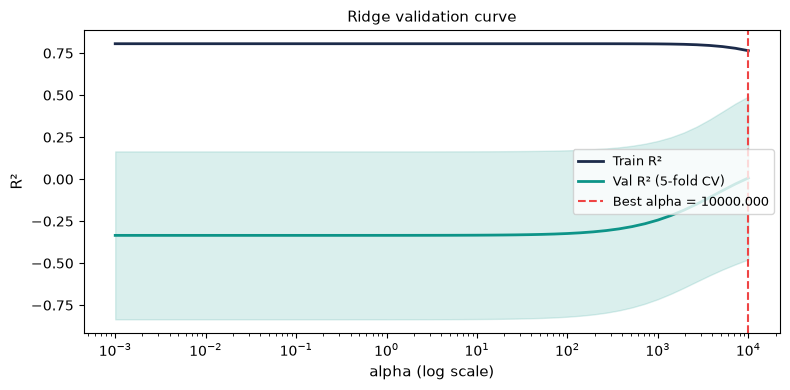

In [6]:
#validation curve shows that ridge regression performs poorly and doesn't generalize well as evidenced by the CV R² scores being lower than the training R² scores. This suggests that ridge regression is not a good fit for this dataset and that a more complex model, such as random forest, may be more appropriate.
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import validation_curve

alphas = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"RidgeCV best alpha: {ridge_cv.alpha_:.4f}")
print(f"Ridge  R²:   {r2_ridge:.3f}")
print(f"Ridge  MAE:  {mae_ridge:.3f} Wh")

# Validation curve
from sklearn.linear_model import Ridge as RidgePlain
tr_scores, val_scores = validation_curve(
    RidgePlain(), X_train_scaled, y_train,
    param_name='alpha', param_range=alphas,
    cv=5, scoring='r2', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, tr_scores.mean(1),  color='#1C2B4A', lw=2, label='Train R²')
ax.semilogx(alphas, val_scores.mean(1), color='#0D9488', lw=2, label='Val R² (5-fold CV)')
ax.fill_between(alphas, val_scores.mean(1)-val_scores.std(1),
                         val_scores.mean(1)+val_scores.std(1), alpha=0.15, color='#0D9488')
ax.axvline(ridge_cv.alpha_, color='#EF4444', lw=1.5, ls='--',
           label=f'Best alpha = {ridge_cv.alpha_:.3f}')
ax.set_xlabel('alpha (log scale)', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Ridge validation curve', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('C2_ridge_validation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
#tuning the model using one fold.
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "rf__n_estimators":     [100, 200, 300, 500],
    "rf__max_depth":        [None, 5, 10, 20],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features":     ["sqrt", "log2", 0.3],
}

rscv = RandomizedSearchCV(
    pipe, param_dist, n_iter=15,
    cv=GroupKFold(n_splits=5),
    scoring="r2", n_jobs=-1, random_state=42, verbose=0
)
rscv.fit(X_train, y_train, groups=groups_train)

best_model    = rscv
best_params   = rscv.best_params_
best_cv_score = rscv.best_score_
print("Method: RandomizedSearchCV (15 random trials)")

Method: RandomizedSearchCV (15 random trials)


In [8]:
#this is just the tuned model executed on one fold.
y_pred_tuned = best_model.predict(X_test)
r2_tuned   = r2_score(y_test, y_pred_tuned)
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

comparison = pd.DataFrame({
    'Model':  ['Default RF', 'Tuned RF (RandomizedSearch)'],
    'R2':     [round(r2_def,3),   round(r2_tuned,3)],
    'MAE':    [round(mae_def,3),  round(mae_tuned,3)],
    'RMSE':   [round(rmse_def,3), round(rmse_tuned,3)],
})
print(comparison.to_string(index=False))


                      Model    R2   MAE  RMSE
                 Default RF 0.991 0.074 0.195
Tuned RF (RandomizedSearch) 0.990 0.074 0.208


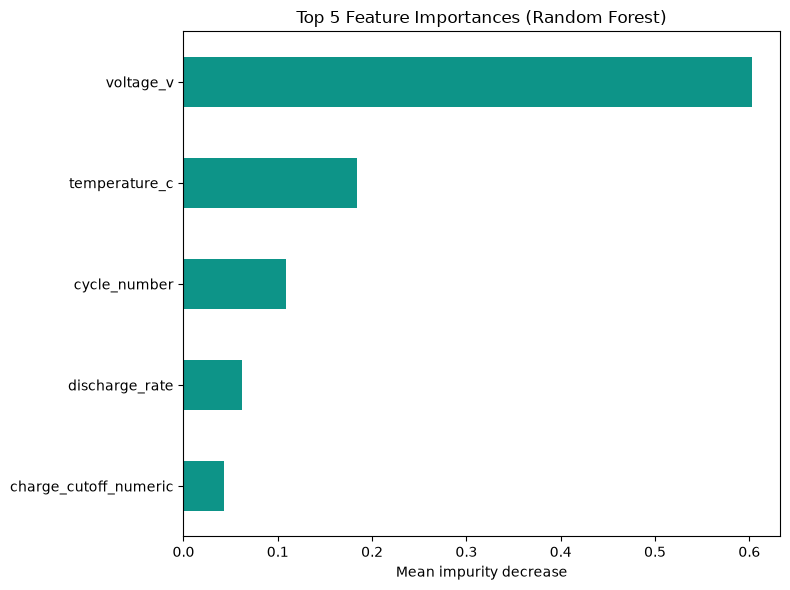

Top 5 features:
voltage_v                0.6024
temperature_c            0.1845
cycle_number             0.1082
discharge_rate           0.0617
charge_cutoff_numeric    0.0432
dtype: float64


In [9]:
best_rf = rscv.best_estimator_.named_steps['rf']
importances = pd.Series(best_rf.feature_importances_, index=model_features)
top = importances.nlargest(5)

fig, ax = plt.subplots(figsize=(8, 6))
top.sort_values().plot(kind='barh', color='#0D9488', ax=ax)
ax.set_xlabel('Mean impurity decrease')
ax.set_title('Top 5 Feature Importances (Random Forest)', fontsize=12)
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print("Top 5 features:")
print(top.head(5).round(4))

In [10]:
#random forest model with GroupKFold cross validation to evaluate the model performance across all folds and collect predictions for further analysis.
all_y_test = []
all_y_pred = []

for train_idx, test_idx in GroupKFold(n_splits=5).split(X_all, y_all, groups):
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_all[train_idx])
    X_test_fold = scaler.transform(X_all[test_idx])

    model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model.fit(X_train_fold, y_all[train_idx])
    preds = model.predict(X_test_fold)

    all_y_test.append(y_all[test_idx])
    all_y_pred.append(preds)

all_y_test = np.concatenate(all_y_test)
all_y_pred = np.concatenate(all_y_pred)

print(len(all_y_test), len(all_y_pred))


91999 91999
